<a href="https://colab.research.google.com/github/annabashlakova/ECON3916-Statistical-Machine-Learning/blob/main/%5BLab_10_%5D_Causality_%26_Spurious_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Step 1
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from pandas_datareader import data as pdr
import warnings
warnings.filterwarnings('ignore')


start = "2010-01-01"
end = "2024-01-01"

series = {
    "CPIAUCSL": "cpi",      # Consumer Price Index
    "UNRATE": "unrate",     # Unemployment Rate
    "FEDFUNDS": "fedfunds", # Fed Funds Rate
    "INDPRO": "indpro",     # Industrial Production
    "M2SL": "m2"            # M2 Money Supply
}

df_list = []
for code, name in series.items():
    s = pdr.DataReader(code, "fred", start, end)
    s.columns = [name]
    df_list.append(s)

df = pd.concat(df_list, axis=1).resample("MS").mean().dropna()
display(df.head())

,cpi,unrate,fedfunds,indpro,m2
DATE,,,,,
2010-01-01,217.488,9.8,0.11,89.3426,8477.7
2010-02-01,217.281,9.8,0.13,89.6779,8527.3
2010-03-01,217.353,9.9,0.16,90.2928,8523.5
2010-04-01,217.403,9.9,0.20,90.5991,8554.8
2010-05-01,217.290,9.6,0.20,91.8230,8609.0


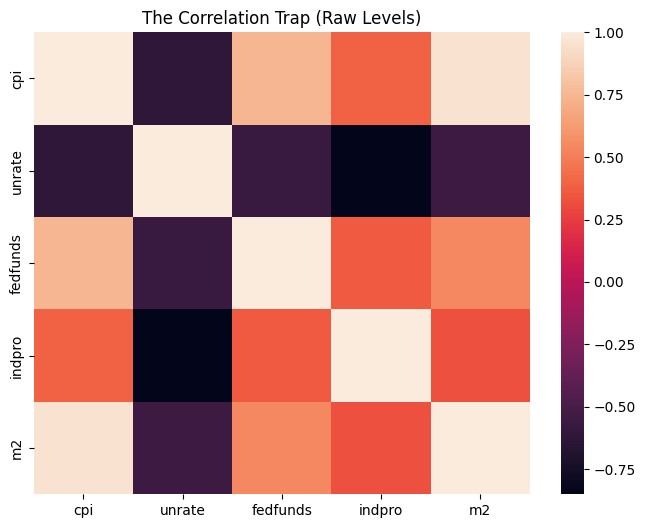

In [3]:
# step 2
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr())
plt.title("The Correlation Trap (Raw Levels)")
plt.show()

In [5]:
# Step 3

X = df[['unrate', 'fedfunds', 'indpro', 'm2']]
X = sm.add_constant(X)

vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

display(vif_data)

,Feature,VIF
0,const,4252.825829
1,unrate,6.206882
2,fedfunds,1.727582
3,indpro,4.290455
4,m2,1.780273


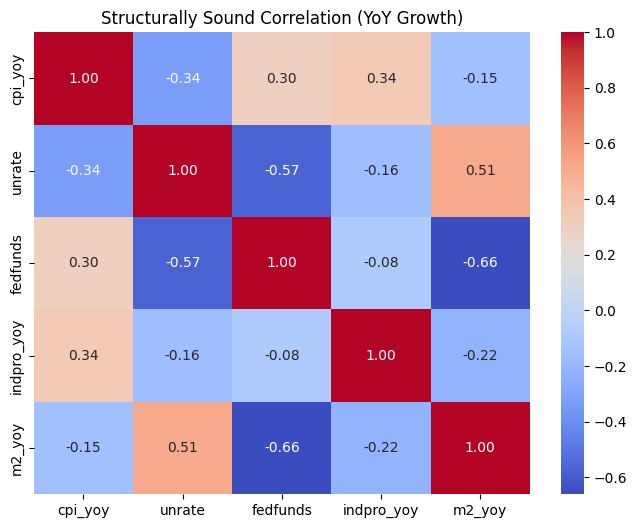

In [6]:
# step 4
df_t = df.copy()

for col in ["cpi", "indpro", "m2"]:
    df_t[f"{col}_yoy"] = 100 * (df_t[col] / df_t[col].shift(12) - 1)


df_t = df_t.dropna()


cols_to_keep = ['cpi_yoy', 'unrate', 'fedfunds', 'indpro_yoy', 'm2_yoy']
plt.figure(figsize=(8, 6))
sns.heatmap(df_t[cols_to_keep].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Structurally Sound Correlation (YoY Growth)")
plt.show()

In [7]:
# Ai expansion
import pandas as pd
import numpy as np
import plotly.graph_objects as go

# ─────────────────────────────────────────────────────────────
# 1. SYNTHETIC FRED-STYLE DATA
#    Replace this block with your actual DataFrame.
#    Expected columns: CPI, Unemployment, FedFunds, IndProd, M2
#    and their YoY counterparts suffixed with _YoY
# ─────────────────────────────────────────────────────────────
np.random.seed(42)
n = 300  # ~25 years of monthly data

dates = pd.date_range("2000-01", periods=n, freq="MS")

# Raw levels — deliberately trended to showcase spurious correlation
trend = np.linspace(0, 1, n)
df = pd.DataFrame({
    "CPI":          100 + 60 * trend + np.random.randn(n) * 2,
    "Unemployment": 8   -  4 * trend + np.random.randn(n) * 0.5,
    "FedFunds":     5   -  4 * trend + np.random.randn(n) * 0.3,
    "IndProd":      90  + 30 * trend + np.random.randn(n) * 3,
    "M2":           7000 + 14000 * trend + np.random.randn(n) * 200,
}, index=dates)

# YoY % change — removes shared deterministic trend
yoy_cols = {col: f"{col}_YoY" for col in df.columns}
for raw, yoy in yoy_cols.items():
    df[yoy] = df[raw].pct_change(12) * 100  # 12-month % change

df.dropna(inplace=True)  # drop first 12 rows that have NaN YoY


# ─────────────────────────────────────────────────────────────
# 2. BUILD CORRELATION MATRICES
# ─────────────────────────────────────────────────────────────
raw_cols = list(yoy_cols.keys())
yoy_cols_list = list(yoy_cols.values())
labels = ["CPI", "Unemp.", "FedFunds", "IndProd", "M2"]  # shared axis labels

corr_raw = df[raw_cols].corr().round(2)
corr_yoy = df[yoy_cols_list].corr().round(2)


# ─────────────────────────────────────────────────────────────
# 3. HELPER — build annotation text matrix for heatmap cells
# ─────────────────────────────────────────────────────────────
def make_annotations(corr_df, labels):
    """Return a 2-D list of formatted strings for Heatmap `text` param."""
    return [[f"{corr_df.iloc[r, c]:.2f}" for c in range(len(labels))]
            for r in range(len(labels))]


# ─────────────────────────────────────────────────────────────
# 4. CREATE THE FIGURE WITH TWO HEATMAP TRACES
#    Trace 0 → Raw levels (visible=True initially)
#    Trace 1 → YoY growth  (visible=False initially)
# ─────────────────────────────────────────────────────────────
fig = go.Figure()

# — Trace 0: raw levels ——————————————————————————————————————
fig.add_trace(go.Heatmap(
    z=corr_raw.values,
    x=labels,
    y=labels,
    zmin=-1, zmax=1,                    # fix scale so colors are comparable
    colorscale="RdBu",                  # red = negative, blue = positive
    reversescale=True,                  # blue = +1 (more intuitive)
    text=make_annotations(corr_raw, labels),
    texttemplate="%{text}",             # render the annotation strings
    textfont={"size": 13, "color": "black"},
    hoverongaps=False,
    showscale=True,
    visible=True,                       # shown by default
    name="Raw Levels",
))

# — Trace 1: YoY growth ——————————————————————————————————————
fig.add_trace(go.Heatmap(
    z=corr_yoy.values,
    x=labels,
    y=labels,
    zmin=-1, zmax=1,
    colorscale="RdBu",
    reversescale=True,
    text=make_annotations(corr_yoy, labels),
    texttemplate="%{text}",
    textfont={"size": 13, "color": "black"},
    hoverongaps=False,
    showscale=True,
    visible=False,                      # hidden until user selects it
    name="YoY Growth Rates",
))


# ─────────────────────────────────────────────────────────────
# 5. DROPDOWN MENU via `updatemenus`
#    Each button carries an `args` payload that Plotly applies
#    to the figure when the button is clicked (see §7 for
#    architecture deep-dive).
# ─────────────────────────────────────────────────────────────
fig.update_layout(
    updatemenus=[dict(
        type="dropdown",
        direction="down",
        x=0.01, xanchor="left",
        y=1.18, yanchor="top",
        showactive=True,
        bgcolor="#f0f4ff",
        bordercolor="#3a5bd9",
        font=dict(size=13),
        buttons=[
            dict(
                label="📊 Raw Levels",
                method="update",            # updates both data + layout
                args=[
                    # arg[0] → trace attributes (keyed by trace index)
                    {"visible": [True, False]},
                    # arg[1] → layout attributes
                    {"title.text": "Correlation Matrix — Raw Levels<br>"
                                   "<sup>Shared trends inflate correlations</sup>"}
                ]
            ),
            dict(
                label="📈 YoY Growth Rates",
                method="update",
                args=[
                    {"visible": [False, True]},
                    {"title.text": "Correlation Matrix — YoY Growth Rates<br>"
                                   "<sup>Trend removed; correlations reflect true co-movement</sup>"}
                ]
            ),
        ]
    )],
    title=dict(
        text="Correlation Matrix — Raw Levels<br>"
             "<sup>Shared trends inflate correlations</sup>",
        x=0.5, xanchor="center",
        font=dict(size=17, family="Georgia, serif"),
    ),
    width=650, height=620,
    margin=dict(t=120, l=80, r=40, b=80),
    paper_bgcolor="#fafbff",
    plot_bgcolor="#fafbff",
    font=dict(family="Georgia, serif", size=12),
    xaxis=dict(side="bottom", tickangle=-30),
)

fig.show()
# fig.write_html("corr_heatmap.html")   # ← save for sharing